<a href="https://colab.research.google.com/github/Pooya-Moayed/Bachelors-Desertation/blob/Classification/Pooya_Project_Classification_Zone_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Loading Data**


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Data - Class1.xlsx',index_col=None)

data.head()

,T1,Td,Pd,Carge,KWmm,Tam,Class 1
0,191,249,8.2,8514,1321,45,2
1,194,251,8.2,7184,1158,45,1
2,194,249,8.2,8546,1350,50,1
3,194,250,8.7,8337,1427,50,1
4,195,250,8.3,8262,1409,45,1


In [ ]:
len(data)

269

# **2. Preparing Data**

In [ ]:
# Split into X and y

X = data.drop('Class 1', axis=1)
y = data['Class 1']

In [ ]:
X

,T1,Td,Pd,Carge,KWmm,Tam
0,191,249,8.2,8514,1321,45
1,194,251,8.2,7184,1158,45
2,194,249,8.2,8546,1350,50
3,194,250,8.7,8337,1427,50
4,195,250,8.3,8262,1409,45
...,...,...,...,...,...,...
264,195,251,7.9,8276,1388,50
265,183,252,7.9,7986,1331,45
266,183,251,7.9,7969,1384,45
267,188,250,9.3,8065,1288,40


In [ ]:
y

0      2
1      1
2      1
3      1
4      1
      ..
264    1
265    4
266    4
267    3
268    2
Name: Class 1, Length: 269, dtype: int64

In [ ]:
# Split data into training and test data

from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train

,T1,Td,Pd,Carge,KWmm,Tam
115,194,252,7.50,8300,1435,40
33,192,250,8.10,8544,1471,40
180,191,250,7.70,8085,1270,45
141,190,251,7.40,8495,1445,40
248,187,249,7.90,8257,1350,45
...,...,...,...,...,...,...
20,196,249,8.40,8591,1299,50
188,191,249,7.75,8067,1325,35
71,194,249,7.90,8232,1312,35
106,186,250,7.50,8290,1335,40


In [ ]:
X_test

,T1,Td,Pd,Carge,KWmm,Tam
30,194,250,8.10,8374,1459,50
116,194,251,7.50,8460,1470,35
79,186,250,8.50,8481,1310,40
127,189,249,7.50,8377,1419,45
190,191,248,7.50,8322,1403,45
137,191,251,7.50,8258,1318,50
202,191,251,7.75,8271,1430,45
45,191,249,8.20,8314,1470,45
173,192,251,7.70,8251,1290,50
239,191,251,8.50,8135,1440,45


In [ ]:
y_train

115    1
33     2
180    2
141    4
248    4
      ..
20     1
188    2
71     1
106    4
102    1
Name: Class 1, Length: 215, dtype: int64

In [ ]:
y_test

30     2
116    1
79     4
127    3
190    2
137    2
202    2
45     3
173    2
239    2
179    1
267    3
220    3
82     4
186    2
185    2
241    3
265    4
104    3
60     2
261    2
184    2
46     3
42     1
181    1
9      3
22     1
193    1
109    2
24     2
113    1
68     1
143    3
217    4
197    3
6      3
120    2
67     1
119    3
118    3
25     3
125    3
165    1
19     1
77     3
209    3
90     3
170    1
93     2
258    2
15     2
150    4
224    4
242    3
Name: Class 1, dtype: int64

In [ ]:
y_test.value_counts()

3    19
2    17
1    12
4     6
Name: Class 1, dtype: int64

In [ ]:
y_train.value_counts()

2    74
3    61
4    43
1    37
Name: Class 1, dtype: int64

##Imbalanced Data

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE

smote = SMOTE(sampling_strategy='minority')
#smote = BorderlineSMOTE(sampling_strategy='not majority')


#Creating new samples by SMOTE sampling
X_sm, y_sm = smote.fit_resample(X,y)

from sklearn.model_selection import train_test_split
import numpy as np

#np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.1, stratify=y_sm)

In [ ]:
from imblearn.over_sampling import ADASYN

sm = ADASYN(sampling_strategy='not majority')
X_sm2, y_sm2 = sm.fit_resample(X, y)

from sklearn.model_selection import train_test_split
import numpy as np

#np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X_sm2, y_sm2, test_size=0.1, stratify=y_sm2)

##Pearson Correlation  (detecting highly correlated data)

<function matplotlib.pyplot.show(*args, **kw)>

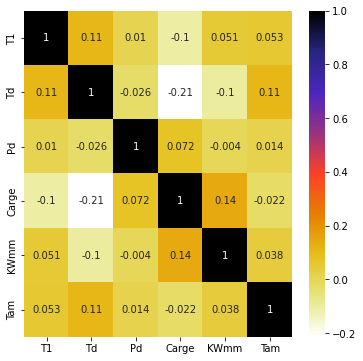

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Using Pearson Correlation
plt.figure(figsize=(6,6))
cor = X.corr(method='pearson')
#cor2 = X.corr(method='spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#sns.heatmap(cor2, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

# **3. Building Machine Learning Model**

# 3.1. Ridge Classification Model

In [ ]:
from sklearn.linear_model import RidgeClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
model = RidgeClassifier()
model.fit(X_train, y_train)

RidgeClassifier()

In [ ]:
#Evaluate our model
model.score(X_test, y_test)

0.46875

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.57407407, 0.59259259, 0.51851852, 0.37037037, 0.56603774])

In [ ]:
#Use the trained model to make predictions

y_preds = model.predict(X_test)
#y_preds[:10]
y_preds

array([3, 3, 1, 3, 1, 2, 3, 1, 4, 1, 1, 4, 3, 1, 1, 1, 4, 1, 1, 1, 1, 1,
       1, 1, 1, 3, 1, 2, 1, 1, 4, 1])

In [ ]:
#y_test[:10]
y_test

49     3
206    3
309    1
212    2
47     2
119    3
211    3
159    1
233    4
62     1
193    1
97     4
199    4
181    1
166    2
176    2
75     4
204    2
194    1
22     1
148    2
44     3
189    2
256    2
95     2
227    4
103    1
58     3
253    2
263    1
267    3
90     3
Name: Class 1, dtype: int64

# 3.2. Random Forest Classification Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
rf = RandomForestClassifier(max_depth= 20,
 max_features= 'auto',
 min_samples_leaf= 1,
 min_samples_split= 8,
 n_estimators= 100)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=8)

In [ ]:
#Evaluate our model
rf.score(X_test, y_test)

0.875

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5)

array([0.61111111, 0.85185185, 0.87037037, 0.72222222, 0.8490566 ])

## 3.3. KNeighbours Classification Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
neigh = KNeighborsClassifier(n_neighbors = 50)
neigh.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=50)

In [ ]:
#Evaluate our model
neigh.score(X_test, y_test)

0.40625

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(neigh, X, y, cv=5)

array([0.2962963 , 0.40740741, 0.27777778, 0.37037037, 0.33962264])

# 3.4. DecisionTree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
#Evaluate our model
dt.score(X_test, y_test)

0.78125

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(dt, X, y, cv=5)

array([0.64814815, 0.81481481, 0.85185185, 0.72222222, 0.79245283])

# 3.5. SVM (Support Vector Machine)

In [ ]:
from sklearn import svm
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
svr = svm.SVC()
svr.fit(X_train,y_train)

SVC()

In [ ]:
#Evaluate our model
svr.score(X_test, y_test)

0.28125

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(svr, X, y, cv=5)

array([0.35185185, 0.33333333, 0.33333333, 0.33333333, 0.33962264])

In [ ]:
y_preds = svr.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
              precision    recall  f1-score   support

           1       0.28      1.00      0.44         9
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         5

    accuracy                           0.28        32
   macro avg       0.07      0.25      0.11        32
weighted avg       0.08      0.28      0.12        32



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 3.6. XGBOOST

In [ ]:
from xgboost import XGBClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
xgb = XGBClassifier( max_depth=50, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train,y_train)

XGBClassifier(max_depth=50, objective='multi:softprob')

In [ ]:
#Evaluate our model
xgb.score(X_test, y_test)

0.9375

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(xgb, X, y, cv=5)

array([0.64814815, 0.90740741, 0.90740741, 0.81481481, 0.81132075])

In [ ]:
y_preds = xgb.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[1.    0.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    0.875 0.125]
 [0.    0.    0.2   0.8  ]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        10
           3       0.88      0.88      0.88         8
           4       0.80      0.80      0.80         5

    accuracy                           0.94        32
   macro avg       0.92      0.92      0.92        32
weighted avg       0.94      0.94      0.94        32



#3.7. CATBOOST

In [ ]:
from catboost import CatBoostClassifier
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
catb =  CatBoostClassifier(iterations=100, learning_rate = 1.0, objective='MultiClass')
catb.fit(X_train,y_train)

0:	learn: 0.6721463	total: 49ms	remaining: 4.85s
1:	learn: 0.5370892	total: 51.5ms	remaining: 2.52s
2:	learn: 0.4703736	total: 53.6ms	remaining: 1.73s
3:	learn: 0.4071598	total: 56.1ms	remaining: 1.35s
4:	learn: 0.3514693	total: 57.9ms	remaining: 1.1s
5:	learn: 0.3237612	total: 60.1ms	remaining: 942ms
6:	learn: 0.2646289	total: 62.4ms	remaining: 829ms
7:	learn: 0.2554560	total: 64.7ms	remaining: 744ms
8:	learn: 0.2271843	total: 66.9ms	remaining: 676ms
9:	learn: 0.2116993	total: 69.1ms	remaining: 622ms
10:	learn: 0.1978698	total: 71.3ms	remaining: 577ms
11:	learn: 0.1871949	total: 73.6ms	remaining: 540ms
12:	learn: 0.1705979	total: 76ms	remaining: 509ms
13:	learn: 0.1609806	total: 78.2ms	remaining: 481ms
14:	learn: 0.1452750	total: 80.5ms	remaining: 456ms
15:	learn: 0.1426187	total: 83.2ms	remaining: 437ms
16:	learn: 0.1337565	total: 85.4ms	remaining: 417ms
17:	learn: 0.1255438	total: 87.7ms	remaining: 399ms
18:	learn: 0.1192389	total: 89.9ms	remaining: 383ms
19:	learn: 0.1102357	total:

In [ ]:
#Evaluate our model
catb.score(X_test, y_test)

0.875

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(catb, X, y, cv=5)

0:	learn: 0.5583922	total: 2.3ms	remaining: 228ms
1:	learn: 0.4009371	total: 5.61ms	remaining: 275ms
2:	learn: 0.3452162	total: 7.61ms	remaining: 246ms
3:	learn: 0.2873415	total: 9.28ms	remaining: 223ms
4:	learn: 0.2506364	total: 12.1ms	remaining: 230ms
5:	learn: 0.2270319	total: 15ms	remaining: 234ms
6:	learn: 0.2161900	total: 17.6ms	remaining: 233ms
7:	learn: 0.1859481	total: 19.6ms	remaining: 225ms
8:	learn: 0.1638765	total: 21.6ms	remaining: 218ms
9:	learn: 0.1486426	total: 23.6ms	remaining: 212ms
10:	learn: 0.1332503	total: 27.9ms	remaining: 226ms
11:	learn: 0.1252273	total: 30ms	remaining: 220ms
12:	learn: 0.1177429	total: 32ms	remaining: 214ms
13:	learn: 0.1148711	total: 33.9ms	remaining: 208ms
14:	learn: 0.1024763	total: 35.8ms	remaining: 203ms
15:	learn: 0.0932093	total: 37.8ms	remaining: 198ms
16:	learn: 0.0861401	total: 39.7ms	remaining: 194ms
17:	learn: 0.0792178	total: 41.8ms	remaining: 190ms
18:	learn: 0.0760648	total: 43.6ms	remaining: 186ms
19:	learn: 0.0720372	total: 4

array([0.64814815, 0.87037037, 0.92592593, 0.75925926, 0.8490566 ])

In [ ]:
y_preds = catb.predict(X_test)
print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
print(classification_report(y_test, y_preds))

nconfusion = [[1.    0.    0.    0.   ]
 [0.    0.8   0.2   0.   ]
 [0.    0.125 0.75  0.125]
 [0.    0.    0.    1.   ]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         9
           2       0.89      0.80      0.84        10
           3       0.75      0.75      0.75         8
           4       0.83      1.00      0.91         5

    accuracy                           0.88        32
   macro avg       0.87      0.89      0.88        32
weighted avg       0.88      0.88      0.87        32



## All Models

In [ ]:
!pip install catboost
!pip install logitboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 1.4 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Test the models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from logitboost import LogitBoost


from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, jaccard_score, fbeta_score, hamming_loss, matthews_corrcoef, log_loss, f1_score, average_precision_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, cohen_kappa_score
from imblearn.metrics import sensitivity_score, specificity_score, geometric_mean_score
import numpy as np

np.random.seed(42)

#X_converted = X.to_numpy()
#y_converted = y.to_numpy()

#X_converted = X_sm2.to_numpy()
#y_converted = y_sm2.to_numpy()

#kfold = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)
kfold = KFold(n_splits=5, random_state=None, shuffle=True)

a=1

#for train_index, test_index in kfold.split(X_converted, y_converted):
#  print("TRAIN:", train_index, "TEST:", test_index)
  #X_train, X_test = X_converted[train_index], X_converted[test_index]
  #y_train, y_test = y_converted[train_index], y_converted[test_index]
for train_index, test_index in kfold.split(X, y):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]


  #Build our model and fit the data
  #model = LogisticRegression()            #useless
  #model = RidgeClassifier()               #useless
  #model = SGDClassifier()                 #a good linear model
  #model = LinearSVC()                     #report the model as a bad sample of linear models (sklearn cheet sheet)
  #model = GaussianNB()                    #useless
  #model = PassiveAggressiveClassifier()   #useless
  model = RandomForestClassifier(n_estimators= 100)
  #model = KNeighborsClassifier(n_neighbors = 100)    #useless
  #model = DecisionTreeClassifier()                   #Best result 71.3%
  #model = SVC()                                      #useless
  #model = ExtraTreesClassifier(n_estimators=100)                     #Best result 78.7%
  #model = GaussianProcessClassifier()                #useless
  #model = XGBClassifier(max_depth=50, learning_rate=1, n_estimators=100)     #Best result 78.7%                                            #1
  #model = XGBClassifier(booster="gbtree")                                                       #Best result 81.3%
  #model = XGBClassifier(booster="dart", rate_drop=0.1, skip_drop=0.5, max_depth=50, learning_rate=1, n_estimators=100)                            #Best result 81.0%
  #model = XGBClassifier(booster="gblinear")                                                     #useless
  #model = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100, random_state=0)                               #Best result 76.8%
  #model = BaggingClassifier(bootstrap=False, max_samples=0.5)   #Pasting Ensemble                                                    #Best result 75%
  #model = BaggingClassifier(bootstrap=False, bootstrap_features=False, max_features=0.66, max_samples=0.66)   #Random Patches        #Best result 75.7%
  #model = BaggingClassifier(bootstrap=False, max_features=10)   #Random Subspaces                             #Best result 77.3%
  #model = GradientBoostingClassifier(n_estimators=100, learning_rate=1 ,max_depth=10)         #Best result 76.2%
  #model = AdaBoostClassifier(n_estimators=100, learning_rate= 1)                           #Best result 77.7%
  #model = CatBoostClassifier(iterations=100, learning_rate = 1.0, objective='MultiClass')                                                          #Best result 79.5%
  #model = LGBMClassifier()                                                                                    #Best result 77.2%
  #model = LGBMClassifier(boosting_type='goss')                                                                #Best result 78.4% // 78%
  #model = LGBMClassifier(boosting_type='dart')                                                                #Best result 78.4%
  #model = RotationForest()
  #model = RRForestClassifier()  #Random Rotation Forest
  #model = RRExtraTreesClassifier()  #Random Rotation Extra Tree
  #model = LogitBoost(n_estimators=100, learning_rate= 1.0)



  model.fit(X_train, y_train)

  y_preds= model.predict(X_test)
  #y_preds_proba = model.predict_proba(X_test)
  print(a)
  #print(model.score(X_test, y_test))

  #print("average_precision_score:", average_precision_score(y_test, y_preds))
  #print(precision_score(y_test, y_preds))
  print("accuracy_score =", accuracy_score(y_test, y_preds))
  print("f1_score =", f1_score(y_test, y_preds, average='macro'))
  #print("auc_score =", roc_auc_score(y_test, y_preds_proba, average='weighted', multi_class='ovo'))
  print("recall_score =", recall_score(y_test, y_preds, average='macro'))
  print("specificity_score =", specificity_score(y_test, y_preds, average='macro'))
  print("gmean_score =", geometric_mean_score(y_test, y_preds, average='macro'))
  print("precision_score = ", precision_score(y_test, y_preds, average='macro'))
  print("jaccard_score =", jaccard_score(y_test, y_preds, average='macro'))
  print("cohen_kappa_score =", cohen_kappa_score(y_test, y_preds))
  print("matthews_corrcoef =", matthews_corrcoef(y_test, y_preds))
  print("hamming_loss =", hamming_loss(y_test, y_preds))
  #print("fbeta_score =", fbeta_score(y_test, y_preds, 1))
  #print("log_loss =", log_loss(y_test, y_preds_proba))
  print("nconfusion =", confusion_matrix(y_test, y_preds, normalize='true'))
  print(classification_report(y_test, y_preds))
  print('*'*50)
  a = a + 1




#data_test = pd.read_excel('/content/drive/MyDrive/Financial Data_2_ranges_Test.xlsx')
#X2 = data_test.drop('Stock return', axis=1)
#y2 = data_test['Stock return']
#y_pred = model.predict(X2.to_numpy())
#print("+++++++++++++++++++FINAL TEST RESULTS (20%)++++++++++++++++++++")
#print("accuracy_score:", accuracy_score(y2,y_pred))
#print(classification_report(y2,y_pred))
#print(confusion_matrix(y2,y_pred))